# Assignment 1: Convergence of Scaled Random Walks to Brownian Motion

**Objective:**
This notebook demonstrates Donsker's Invariance Principle by simulating a scaled symmetric random walk and verifying its convergence to standard Brownian motion as the number of steps $n \to \infty$.

**Theoretical Setup:**
Let $Z_i$ be independent random variables taking values in $\{-1, 1\}$ with equal probability. We define the scaled random walk $X_t^{(n)}$ on the interval $[0, T]$ as:

$$X_t^{(n)} = \frac{1}{\sqrt{n}} \sum_{i=1}^{\lfloor nt \rfloor} Z_i$$

As $n$ grows, this discrete process approximates a continuous Wiener process (Brownian motion), which is a fundamental building block for stochastic calculus and modeling asset prices.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Setting plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (10, 6),
    'lines.linewidth': 1.5
})

## Part (a): Scaled Walk Function
We implement a highly optimized, vectorized Python function to generate the discretization of $X_t^{(n)}$. Vectorization is crucial here to ensure performance scales when we later generate tens of thousands of paths.

In [8]:
def scaled_walk(n, T):
    """
    Generates a scaled random walk X_t^(n) on [0, T] with n steps per unit time.
    """
    num_steps = int(np.floor(n * T))
    
    # Fast vectorized generation of {-1, 1} steps
    steps = np.where(np.random.rand(num_steps) < 0.5, -1, 1)
    
    # Cumulative sum scaled by 1/sqrt(n)
    walk = np.concatenate(([0], np.cumsum(steps))) / np.sqrt(n)
    time_grid = np.arange(num_steps + 1) / n
    
    return time_grid, walk

## Part (b): Visualizing Path Convergence
We plot 5 independent sample paths for increasing values of $n$ ($10, 100, 1000, 10000$). It is observed how the macroscopic jumps vanish at higher resolutions, resulting in the continuous, fractal-like oscillation characteristic of Brownian motion.

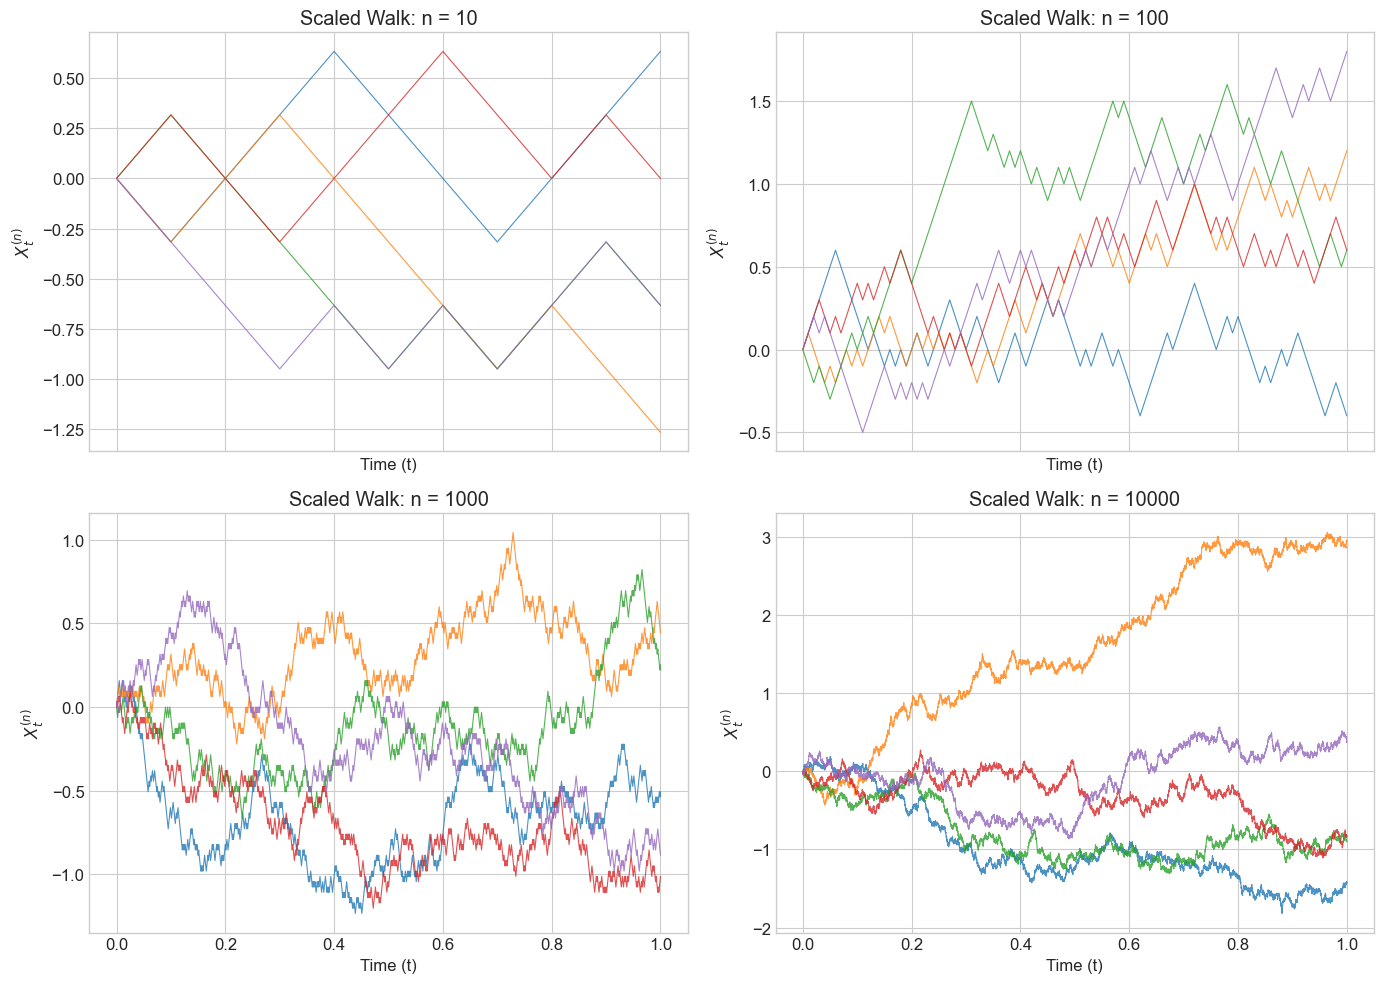

In [9]:
T = 1.0
n_values = [10, 100, 1000, 10000]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

np.random.seed(42) # For reproducible visualizations

for i, n in enumerate(n_values):
    ax = axes[i]
    for _ in range(5):
        t, x = scaled_walk(n, T)
        ax.plot(t, x, alpha=0.8, linewidth=0.8)
    
    ax.set_title(f"Scaled Walk: n = {n}")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel(r"$X_t^{(n)}$")

plt.tight_layout()
plt.show()

## Part (c): Verifying the Variance
For standard Brownian motion $W_t$, the variance at time $t$ is exactly $t$. Therefore, at $t=1$, we expect $\text{Var}(X_1^{(n)}) \to 1$. We verify this empirically across 1000 independent paths.

In [27]:
n_c = 1000
num_paths_c = 1000

# Vectorized simulation across all paths simultaneously
steps_matrix = np.where(np.random.rand(num_paths_c, n_c) < 0.5, -1, 1)
endpoints_c = np.sum(steps_matrix, axis=1) / np.sqrt(n_c)

empirical_var = np.var(endpoints_c, ddof=1)
print(f"Empirical variance at n={n_c} over {num_paths_c} paths: {empirical_var:.4f}")

Empirical variance at n=1000 over 1000 paths: 1.0059


## Part (d): Verifying the Marginal Distribution
By the Central Limit Theorem, the sum of independent increments should converge to a normal distribution. We overlay the empirical histogram of 10,000 paths at $t=1$ with the theoretical Gaussian density $\mathcal{N}(0,1)$.

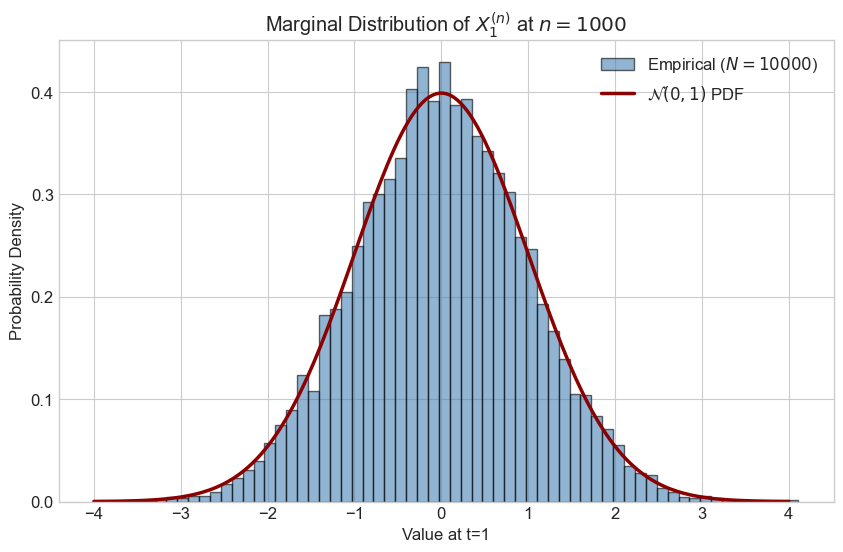

Self-check Variance (n=1000, 10000 paths): 0.9903


In [31]:
n_d = 1000
num_paths_d = 10000

steps_matrix_d = np.where(np.random.rand(num_paths_d, n_d) < 0.5, -1, 1)
endpoints_d = np.sum(steps_matrix_d, axis=1) / np.sqrt(n_d)

plt.figure(figsize=(10, 6))

# Empirical histogram
plt.hist(endpoints_d, bins=60, density=True, alpha=0.6, 
         color='steelblue', edgecolor='black', label=f"Empirical ($N={num_paths_d}$)")

# Theoretical Gaussian PDF
x_axis = np.linspace(-4, 4, 200)
plt.plot(x_axis, norm.pdf(x_axis, 0, 1), color='darkred', linewidth=2.5, label=r"$\mathcal{N}(0,1)$ PDF")

plt.title(r"Marginal Distribution of $X_1^{(n)}$ at $n=1000$")
plt.xlabel("Value at t=1")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

print(f"Self-check Variance (n={n_d}, {num_paths_d} paths): {np.var(endpoints_d, ddof=1):.4f}")